#### 1. 讀取鄉鎮市區界線圖資，擷取花蓮縣吉安鄉

In [13]:
# ============================================================
# Cell 1：讀取鄉鎮市區界線圖資，擷取花蓮縣吉安鄉
# ============================================================

import sys
import subprocess
from pathlib import Path

# ------------------------------------------------------------
# 1. 安裝必要套件
# ------------------------------------------------------------

packages = [
    "geopandas",
    "shapely",
    "fiona",
    "pyproj"
]

for package in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        package
    ])

# ------------------------------------------------------------
# 2. 匯入套件
# ------------------------------------------------------------

import geopandas as gpd
import pandas as pd

# ------------------------------------------------------------
# 3. 設定圖資路徑
# ------------------------------------------------------------

town_shp_path = Path("../data/鄉鎮市區界線/TOWN_MOI_1140318.shp")

if not town_shp_path.exists():
    raise FileNotFoundError(
        f"找不到圖資檔案：{town_shp_path.resolve()}\n"
        "請確認 notebook 位置是否正確，以及 ../data/鄉鎮市區界線/ 中是否有 TOWN_MOI_1140318.shp。"
    )

# ------------------------------------------------------------
# 4. 讀取鄉鎮市區界線圖資
# ------------------------------------------------------------

town_gdf = gpd.read_file(town_shp_path)

print("鄉鎮市區界線圖資讀取完成。")
print(f"總筆數：{len(town_gdf)}")
print(f"CRS：{town_gdf.crs}")
print("欄位名稱：")
print(town_gdf.columns.tolist())

# ------------------------------------------------------------
# 5. 檢查必要欄位
# ------------------------------------------------------------

required_cols = ["COUNTYNAME", "TOWNNAME"]

missing_cols = [
    col for col in required_cols
    if col not in town_gdf.columns
]

if len(missing_cols) > 0:
    raise KeyError(
        f"圖資缺少必要欄位：{missing_cols}\n"
        f"目前欄位有：{town_gdf.columns.tolist()}"
    )

# ------------------------------------------------------------
# 6. 清理文字欄位，避免空白造成篩選失敗
# ------------------------------------------------------------

town_gdf["COUNTYNAME_clean"] = (
    town_gdf["COUNTYNAME"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

town_gdf["TOWNNAME_clean"] = (
    town_gdf["TOWNNAME"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

# ------------------------------------------------------------
# 7. 擷取花蓮縣吉安鄉，儲存為 GEAN 變數
# ------------------------------------------------------------

GEAN = town_gdf[
    (town_gdf["COUNTYNAME_clean"] == "花蓮縣") &
    (town_gdf["TOWNNAME_clean"] == "吉安鄉")
].copy()

# 移除清理用欄位
GEAN = GEAN.drop(
    columns=["COUNTYNAME_clean", "TOWNNAME_clean"],
    errors="ignore"
)

if GEAN.empty:
    raise ValueError(
        "沒有篩選到花蓮縣吉安鄉。\n"
        "請檢查 COUNTYNAME 與 TOWNNAME 欄位中的實際文字內容。"
    )

print("\n成功擷取花蓮縣吉安鄉。")
print(f"GEAN 筆數：{len(GEAN)}")
print(f"GEAN CRS：{GEAN.crs}")

display(GEAN)

鄉鎮市區界線圖資讀取完成。
總筆數：368
CRS：GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
欄位名稱：
['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']

成功擷取花蓮縣吉安鄉。
GEAN 筆數：1
GEAN CRS：GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


,TOWNID,TOWNCODE,COUNTYNAME,TOWNNAME,TOWNENG,COUNTYID,COUNTYCODE,geometry
180,U05,10015050,花蓮縣,吉安鄉,Ji'an Township,U,10015,"POLYGON ((121.55764 23.99829, 121.55798 23.998..."


#### 2. 從 OSM 擷取 GEAN 範圍內的學校圖資，並加入每個學校所在的鄉鎮市區與村里

套件匯入完成。
GEAN 範圍確認完成。
GEAN CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
GEAN 已轉換為 WGS84。
正在從 OSM 下載 GEAN 範圍內的學校資料...
OSM 學校資料下載完成。
within GEAN 的學校數量：15
已讀取村里界線：..\data\村里界圖\VILLAGE_NLSC_1140825.shp
村里界線筆數：7954
村里界線 CRS：GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
村里界線欄位：
['VILLCODE', 'COUNTYNAME', 'TOWNNAME', 'VILLNAME', 'VILLENG', 'COUNTYID', 'COUNTYCODE', 'TOWNID', 'TOWNCODE', 'NOTE', 'geometry']

GEAN 範圍內共找到 15 筆 within 學校資料。

===== 學校名稱、位置、鄉鎮市區與村里 =====


,school_name,amenity,縣市,鄉鎮市區,縣市及鄉鎮市區,村里,longitude,latitude,geometry
0,花蓮高農畜產保健科,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,仁和村,121.585919,23.956486,"POLYGON ((121.58452 23.95615, 121.58657 23.955..."
1,光華國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,光華村,121.578293,23.935842,"POLYGON ((121.57953 23.93578, 121.57896 23.934..."
2,北昌國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,北昌村,121.591690,23.987073,"POLYGON ((121.5925 23.98751, 121.59186 23.9866..."
3,上騰工商,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,吉安村,121.557833,23.972555,"POLYGON ((121.55699 23.97361, 121.5592 23.9723..."
4,吉安國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,吉安村,121.562547,23.973740,"POLYGON ((121.56162 23.97347, 121.56216 23.974..."
5,太昌國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,太昌村,121.565298,23.994401,"POLYGON ((121.56528 23.99596, 121.56631 23.995..."
6,宜昌國中,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,宜昌村,121.587495,23.972011,"POLYGON ((121.58799 23.97301, 121.58846 23.972..."
7,宜昌國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,宜昌村,121.585738,23.970678,"POLYGON ((121.58608 23.97181, 121.58691 23.971..."
8,花蓮特殊教育學校,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,宜昌村,121.584484,23.971447,"POLYGON ((121.58438 23.9726, 121.58559 23.9718..."
9,南華國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,干城村,121.547443,23.947791,"POLYGON ((121.54673 23.94714, 121.54751 23.949..."



===== 村里統計 =====
村里
宜昌村    3
吉安村    2
東昌村    2
北昌村    1
光華村    1
仁和村    1
太昌村    1
干城村    1
慶豐村    1
福興村    1
稻香村    1
Name: count, dtype: int64
學校圖資擷取、within 村里套疊與顯示完成。


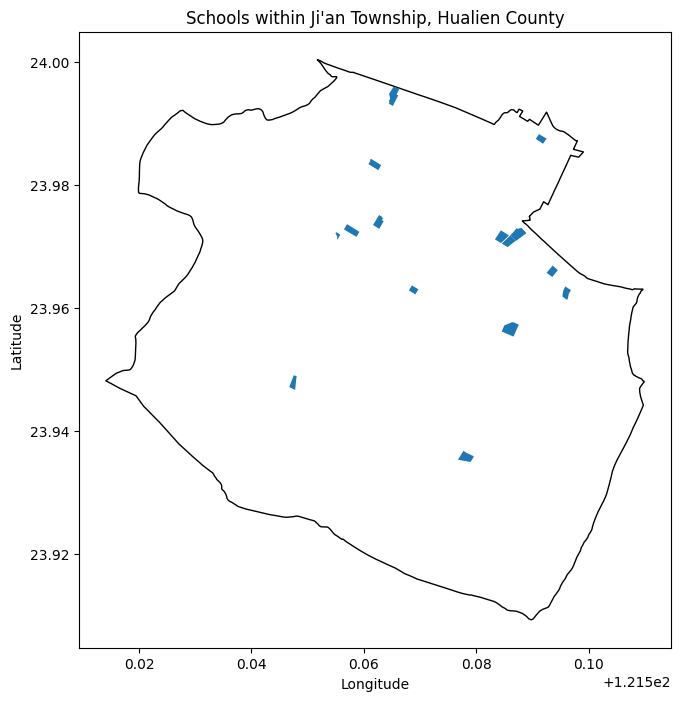

In [14]:
# ============================================================
# Cell 2：從 OSM 擷取 GEAN 範圍內的學校圖資，
#         並加入每個學校所在的鄉鎮市區與村里
#         注意：全程只使用 within，不使用 intersects
# ============================================================

import sys
import subprocess
from pathlib import Path

# ------------------------------------------------------------
# 1. 安裝必要套件
# ------------------------------------------------------------

packages = [
    "osmnx",
    "geopandas",
    "shapely",
    "pandas"
]

for package in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        package
    ])

# ------------------------------------------------------------
# 2. 匯入套件
# ------------------------------------------------------------

import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

print("套件匯入完成。")

# ------------------------------------------------------------
# 3. 檢查 GEAN 是否存在
# ------------------------------------------------------------

if "GEAN" not in globals():
    raise NameError("找不到 GEAN 變數，請先執行前一個擷取花蓮縣吉安鄉範圍的 Cell。")

if GEAN.empty:
    raise ValueError("GEAN 是空的，無法查詢 OSM 學校資料。")

print("GEAN 範圍確認完成。")
print(f"GEAN CRS: {GEAN.crs}")

# ------------------------------------------------------------
# 4. 將 GEAN 轉為 WGS84，因為 OSM 使用 EPSG:4326
# ------------------------------------------------------------

GEAN_wgs84 = GEAN.to_crs(epsg=4326)

# 合併吉安鄉邊界成單一 polygon
gean_polygon = GEAN_wgs84.geometry.union_all()

print("GEAN 已轉換為 WGS84。")

# ------------------------------------------------------------
# 5. 從 OSM 擷取學校相關圖資
# ------------------------------------------------------------

tags = {
    "amenity": [
        "school",
        "college",
        "university"
    ]
}

print("正在從 OSM 下載 GEAN 範圍內的學校資料...")

try:
    schools_osm = ox.features_from_polygon(
        gean_polygon,
        tags=tags
    )
except AttributeError:
    schools_osm = ox.geometries_from_polygon(
        gean_polygon,
        tags=tags
    )

print("OSM 學校資料下載完成。")

# ------------------------------------------------------------
# 6. 整理學校資料
# ------------------------------------------------------------

if schools_osm.empty:
    raise ValueError("GEAN 範圍內未查詢到 OSM 學校資料。")

schools_gdf = schools_osm.copy()

# 確保 CRS 為 WGS84
if schools_gdf.crs is None:
    schools_gdf = schools_gdf.set_crs(epsg=4326)
else:
    schools_gdf = schools_gdf.to_crs(epsg=4326)

# ------------------------------------------------------------
# 7. 建立學校代表點
#    若是 Polygon / MultiPolygon，使用 representative_point()
#    若是 Point，直接使用該點
# ------------------------------------------------------------

schools_gdf["school_point"] = schools_gdf.geometry.apply(
    lambda geom: geom if geom.geom_type == "Point" else geom.representative_point()
)

schools_gdf["longitude"] = schools_gdf["school_point"].apply(lambda p: p.x)
schools_gdf["latitude"] = schools_gdf["school_point"].apply(lambda p: p.y)

# 將 geometry 改為學校代表點，後續所有 within 都以點位判斷
schools_points_gdf = schools_gdf.copy()
schools_points_gdf = schools_points_gdf.set_geometry("school_point")
schools_points_gdf = schools_points_gdf.set_crs(epsg=4326, allow_override=True)

# ------------------------------------------------------------
# 8. 只保留 within GEAN 的學校點位
#    注意：這裡不使用 intersects
# ------------------------------------------------------------

schools_points_gdf = schools_points_gdf[
    schools_points_gdf.geometry.within(gean_polygon)
].copy()

if schools_points_gdf.empty:
    raise ValueError("OSM 有下載到資料，但沒有學校代表點位完全位於吉安鄉範圍內。")

print(f"within GEAN 的學校數量：{len(schools_points_gdf)}")

# ------------------------------------------------------------
# 9. 加入縣市及鄉鎮市區欄位
# ------------------------------------------------------------

schools_points_gdf["縣市"] = "花蓮縣"
schools_points_gdf["鄉鎮市區"] = "吉安鄉"
schools_points_gdf["縣市及鄉鎮市區"] = "花蓮縣吉安鄉"

# ------------------------------------------------------------
# 10. 讀取村里界線
# ------------------------------------------------------------

candidate_village_paths = [
    Path("../data/村里界圖/VILLAGE_NLSC_1140825.shp")
]

village_path = None

for path in candidate_village_paths:
    if path.exists():
        village_path = path
        break

if village_path is None:
    raise FileNotFoundError(
        "找不到村里界線圖資。\n"
        "請確認村里界線 shp 是否位於以下路徑：\n"
        + "\n".join([str(p) for p in candidate_village_paths])
    )

village_gdf = gpd.read_file(village_path)

print(f"已讀取村里界線：{village_path}")
print(f"村里界線筆數：{len(village_gdf)}")
print(f"村里界線 CRS：{village_gdf.crs}")
print("村里界線欄位：")
print(village_gdf.columns.tolist())

# ------------------------------------------------------------
# 11. 篩選花蓮縣吉安鄉村里
# ------------------------------------------------------------

# 清理文字欄位
for col in village_gdf.columns:
    if village_gdf[col].dtype == "object":
        village_gdf[col] = village_gdf[col].astype(str).str.strip()

county_col_candidates = ["COUNTYNAME", "COUNTY", "COUNTY_NAME", "縣市"]
town_col_candidates = ["TOWNNAME", "TOWN", "TOWN_NAME", "鄉鎮市區"]
village_col_candidates = ["VILLNAME", "VILLAGE", "VILLAGE_NAME", "村里", "村里名稱"]

county_col = next((col for col in county_col_candidates if col in village_gdf.columns), None)
town_col = next((col for col in town_col_candidates if col in village_gdf.columns), None)
village_col = next((col for col in village_col_candidates if col in village_gdf.columns), None)

if village_col is None:
    raise KeyError(
        "村里界線圖資中找不到村里名稱欄位。\n"
        f"目前欄位有：{village_gdf.columns.tolist()}"
    )

if county_col is not None:
    village_gdf = village_gdf[
        village_gdf[county_col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace("　", "", regex=False) == "花蓮縣"
    ].copy()

if town_col is not None:
    village_gdf = village_gdf[
        village_gdf[town_col]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace("　", "", regex=False) == "吉安鄉"
    ].copy()

if village_gdf.empty:
    raise ValueError(
        "村里界線篩選花蓮縣吉安鄉後為空。\n"
        "請檢查村里界線圖資的 COUNTYNAME / TOWNNAME 欄位內容。"
    )

# 轉成 WGS84 與學校點位一致
village_gdf = village_gdf.to_crs(epsg=4326)

# 只保留村里名稱與 geometry
village_for_join = village_gdf[[village_col, "geometry"]].copy()
village_for_join = village_for_join.rename(columns={village_col: "村里"})

# ------------------------------------------------------------
# 12. Spatial join：只使用 within 找出每個學校所在村里
#    注意：完全不使用 intersects
# ------------------------------------------------------------

schools_points_gdf = gpd.sjoin(
    schools_points_gdf,
    village_for_join,
    how="left",
    predicate="within"
)

schools_points_gdf = schools_points_gdf.drop(
    columns=["index_right"],
    errors="ignore"
)

missing_village_count = schools_points_gdf["村里"].isna().sum()

if missing_village_count > 0:
    print(f"提醒：有 {missing_village_count} 筆學校未以 within 對應到村里。")
    print("這些點可能位於村里邊界上，或村里圖資與 OSM 點位存在些微位置差異。")
    print("依照你的要求，本程式不使用 intersects 補值。")

# ------------------------------------------------------------
# 13. 整理名稱欄位
# ------------------------------------------------------------

if "name" not in schools_points_gdf.columns:
    schools_points_gdf["name"] = "未提供名稱"

schools_points_gdf["school_name"] = schools_points_gdf["name"].fillna("未提供名稱")

# ------------------------------------------------------------
# 14. 整理要顯示與儲存的欄位
# ------------------------------------------------------------

display_cols = [
    "school_name",
    "amenity",
    "縣市",
    "鄉鎮市區",
    "縣市及鄉鎮市區",
    "村里",
    "longitude",
    "latitude",
    "geometry"
]

existing_display_cols = [
    col for col in display_cols
    if col in schools_points_gdf.columns
]

schools_list = schools_points_gdf[existing_display_cols].copy()

# 依村里與名稱排序
sort_cols = [col for col in ["村里", "school_name"] if col in schools_list.columns]

schools_list = schools_list.sort_values(
    by=sort_cols
).reset_index(drop=True)

# 同步更新 schools_gdf，後續分析建議使用點位 geometry
schools_gdf = schools_list.copy()

schools_gdf = gpd.GeoDataFrame(
    schools_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# 15. 顯示結果
# ------------------------------------------------------------

print(f"\nGEAN 範圍內共找到 {len(schools_list)} 筆 within 學校資料。")

print("\n===== 學校名稱、位置、鄉鎮市區與村里 =====")
display(schools_list)

print("\n===== 村里統計 =====")
print(schools_list["村里"].value_counts(dropna=False))

# ------------------------------------------------------------
# 16. 簡單繪圖檢查
# ------------------------------------------------------------

ax = GEAN_wgs84.plot(
    figsize=(8, 8),
    edgecolor="black",
    facecolor="none"
)

schools_gdf.plot(
    ax=ax,
    markersize=30
)

ax.set_title("Schools within Ji'an Township, Hualien County")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

print("學校圖資擷取、within 村里套疊與顯示完成。")

#### 3.存檔與檢查

In [15]:
import os

# 建立輸出資料夾路徑
output_dir = "../output"

# 如果 output 資料夾不存在，就自動建立
os.makedirs(output_dir, exist_ok=True)

# 設定輸出檔案路徑
output_csv_path = os.path.join(output_dir, "schools_list.csv")

# 輸出 CSV
schools_list.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"已成功輸出檔案至：{output_csv_path}")

已成功輸出檔案至：../output\schools_list.csv


In [16]:
schools_list

,school_name,amenity,縣市,鄉鎮市區,縣市及鄉鎮市區,村里,longitude,latitude,geometry
0,花蓮高農畜產保健科,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,仁和村,121.585919,23.956486,"POLYGON ((121.58452 23.95615, 121.58657 23.955..."
1,光華國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,光華村,121.578293,23.935842,"POLYGON ((121.57953 23.93578, 121.57896 23.934..."
2,北昌國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,北昌村,121.591690,23.987073,"POLYGON ((121.5925 23.98751, 121.59186 23.9866..."
3,上騰工商,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,吉安村,121.557833,23.972555,"POLYGON ((121.55699 23.97361, 121.5592 23.9723..."
4,吉安國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,吉安村,121.562547,23.973740,"POLYGON ((121.56162 23.97347, 121.56216 23.974..."
5,太昌國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,太昌村,121.565298,23.994401,"POLYGON ((121.56528 23.99596, 121.56631 23.995..."
6,宜昌國中,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,宜昌村,121.587495,23.972011,"POLYGON ((121.58799 23.97301, 121.58846 23.972..."
7,宜昌國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,宜昌村,121.585738,23.970678,"POLYGON ((121.58608 23.97181, 121.58691 23.971..."
8,花蓮特殊教育學校,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,宜昌村,121.584484,23.971447,"POLYGON ((121.58438 23.9726, 121.58559 23.9718..."
9,南華國小,school,花蓮縣,吉安鄉,花蓮縣吉安鄉,干城村,121.547443,23.947791,"POLYGON ((121.54673 23.94714, 121.54751 23.949..."
